## Agenda

- Decision tables, indiscernibility, and approximate reducts (recap)
- What does a reduct look like? (Golf dataset example)
- Why it matters: classification gain and feature importance
- What takes long: profiling the bottleneck
- GroupIndex: the core data structure and its API
- GroupIndex implementations: from lazy to inverted index
- Benchmarks and end-to-end experiments
- (Bonus) Hook architecture for building algorithms

## Decision Tables

A decision table is a tuple $(U, A \cup \{d\})$:

- $U$ -- universe of objects
- $A$ -- conditional attributes
- $d$ -- decision attribute

**Example: Play Golf**

| Outlook | Temperature | Humidity | Wind | Play |
|---------|-------------|----------|------|------|
| sunny | hot | high | weak | no |
| sunny | hot | high | strong | no |
| overcast | hot | high | weak | yes |
| rain | mild | high | weak | yes |
| ... | ... | ... | ... | ... |

$|A| = 4$, $|U| = 14$, $V_d = \{\text{yes}, \text{no}\}$

## Indiscernibility & Disorder Measures

Given $B \subseteq A$, objects $u, v \in U$ are **indiscernible** iff they have the same
values on all attributes in $B$:

$$u \, IND(B) \, v \iff \forall a \in B: a(u) = a(v)$$

Each $B$ partitions $U$ into **equivalence classes** (groups).

A **disorder measure** quantifies how impure the decision values are within groups:

- **Entropy**: $-\sum p_i \log_2 p_i$
- **Gini impurity**: $1 - \sum p_i^2$
- **Conflicts count**: number of conflicting object pairs

Goal: find $B$ that makes groups as pure as possible (low disorder).

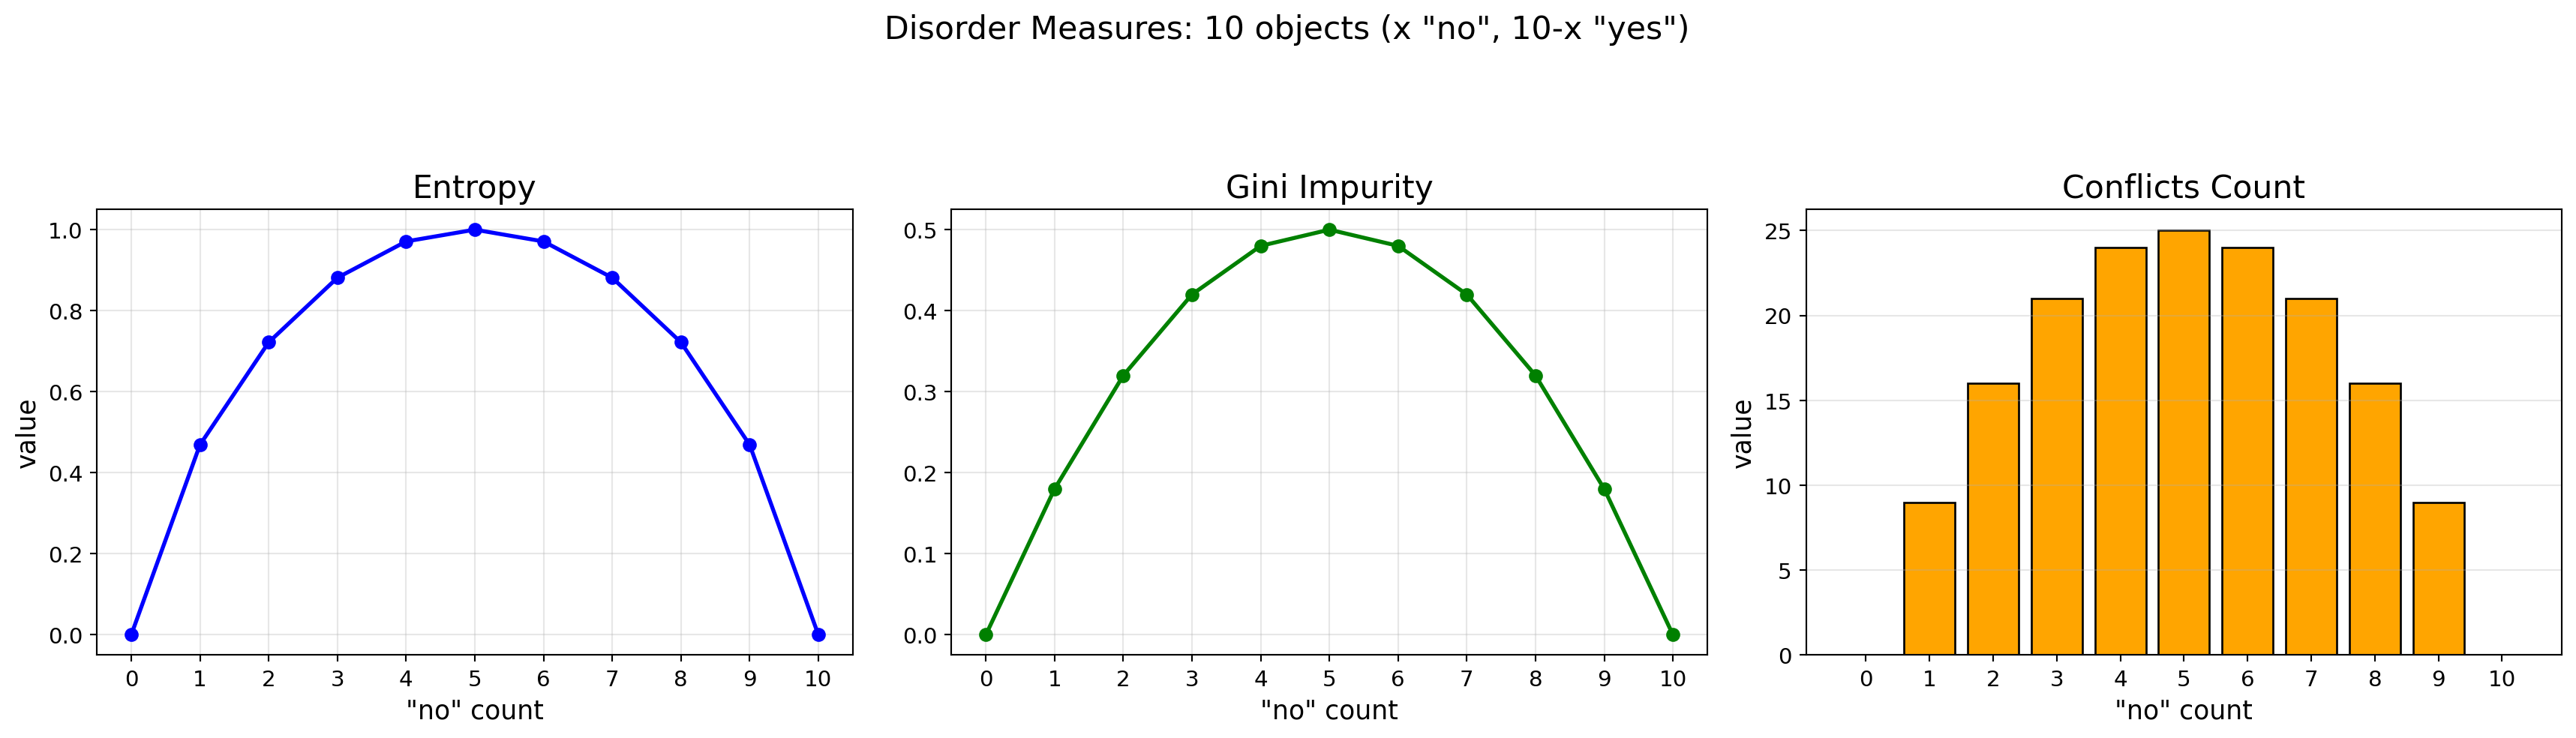

In [1]:
# | output: false
import matplotlib.pyplot as plt
import numpy as np

n = 10
x_vals = np.arange(n + 1)
p = x_vals / n

with np.errstate(divide="ignore", invalid="ignore"):
    entropy_vals = np.where(
        (p > 0) & (p < 1),
        -p * np.log2(p) - (1 - p) * np.log2(1 - p),
        0.0,
    )

gini_vals = 1 - p**2 - (1 - p) ** 2
conflicts_vals = x_vals * (n - x_vals)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(x_vals, entropy_vals, "b-o", linewidth=2, markersize=6)
axes[0].set_title("Entropy", fontsize=16)
axes[0].set_xlabel('"no" count', fontsize=13)
axes[0].set_ylabel("value", fontsize=13)
axes[0].tick_params(labelsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_vals, gini_vals, "g-o", linewidth=2, markersize=6)
axes[1].set_title("Gini Impurity", fontsize=16)
axes[1].set_xlabel('"no" count', fontsize=13)
axes[1].tick_params(labelsize=11)
axes[1].grid(True, alpha=0.3)

axes[2].bar(x_vals, conflicts_vals, color="orange", edgecolor="black")
axes[2].set_title("Conflicts Count", fontsize=16)
axes[2].set_xlabel('"no" count', fontsize=13)
axes[2].set_ylabel("value", fontsize=13)
axes[2].tick_params(labelsize=11)
axes[2].grid(True, alpha=0.3, axis="y")

for ax in axes:
    ax.set_xticks(x_vals)

plt.suptitle('Disorder Measures: 10 objects (x "no", 10-x "yes")', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.savefig("figures/disorder_measures.png", dpi=200, bbox_inches="tight")
plt.show()

## Disorder Measures: Visual Comparison

![disorder measures](figures/disorder_measures.png){.column-screen-inset fig-align="center" width="100%"}

10 objects, varying split between "no" and "yes" decisions.
All three measures agree: pure groups (0 or 10) have zero disorder, maximum at 5/5 split.

## Approximate Reducts

Given a decision table and $\varepsilon \in [0, 1)$:

- **Base disorder**: disorder with all objects in one group (no attributes)
- **Total disorder**: disorder with all attributes $A$
- **Threshold**: $T = total + \varepsilon \cdot (base - total)$

A subset $B \subseteq A$ is an **$\varepsilon$-approximate decision reduct** iff:

$$disorder\_score(B) \leq T$$

and no proper subset of $B$ satisfies this.

Intuition: $\varepsilon = 0$ means a full reduct (max quality).
$\varepsilon > 0$ means we accept some loss for fewer attributes.

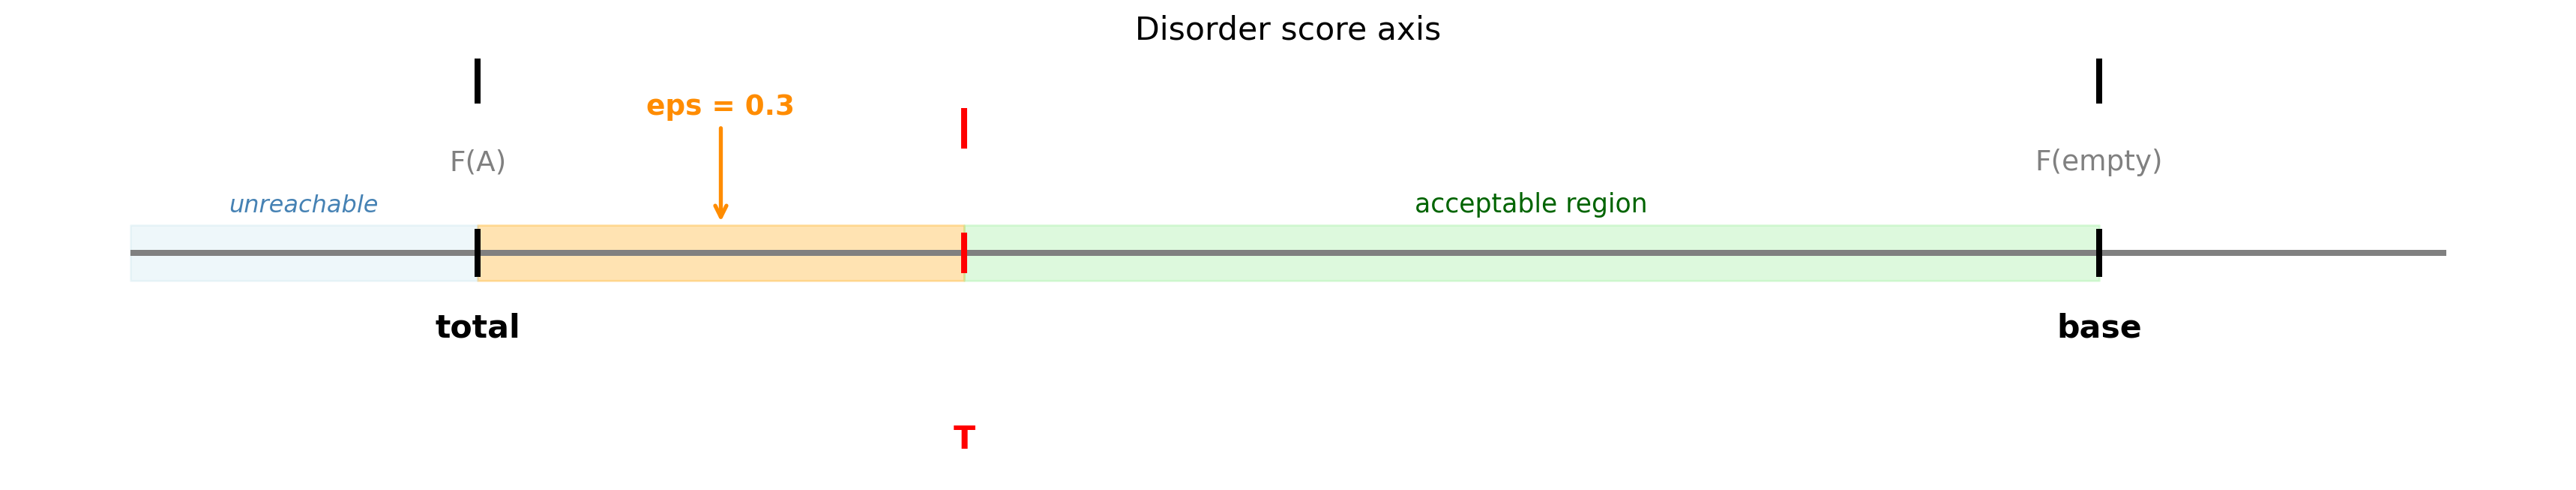

In [2]:
# | output: false
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(18, 3.5))

total = 0.15
base = 0.85
eps = 0.3
T = total + eps * (base - total)

ax.hlines(y=0, xmin=0, xmax=1, color="gray", linewidth=3)

ax.plot([total, total], [0, 0.25], "k|", markersize=24, markeredgewidth=3)
ax.text(total, -0.12, "total", ha="center", fontsize=16, fontweight="bold")
ax.text(total, 0.12, "F(A)", ha="center", fontsize=14, color="gray")

ax.plot([base, base], [0, 0.25], "k|", markersize=24, markeredgewidth=3)
ax.text(base, -0.12, "base", ha="center", fontsize=16, fontweight="bold")
ax.text(base, 0.12, "F(empty)", ha="center", fontsize=14, color="gray")

ax.plot([T, T], [0, 0.18], "r|", markersize=20, markeredgewidth=3)
ax.text(T, -0.28, "T", ha="center", fontsize=16, color="red", fontweight="bold")

ax.fill_betweenx(
    y=[-0.04, 0.04],
    x1=total,
    x2=T,
    color="orange",
    alpha=0.3,
)
ax.annotate(
    f"eps = {eps}",
    xy=((total + T) / 2, 0.04),
    xytext=((total + T) / 2, 0.2),
    ha="center",
    fontsize=14,
    color="darkorange",
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="darkorange", lw=2),
)

ax.fill_betweenx(
    y=[-0.04, 0.04],
    x1=T,
    x2=base,
    color="lightgreen",
    alpha=0.3,
)
ax.text(
    (T + base) / 2,
    0.06,
    "acceptable region",
    ha="center",
    fontsize=13,
    color="darkgreen",
)

ax.fill_betweenx(
    y=[-0.04, 0.04],
    x1=0,
    x2=total,
    color="lightblue",
    alpha=0.2,
)
ax.text(
    total / 2,
    0.06,
    "unreachable",
    ha="center",
    fontsize=12,
    color="steelblue",
    style="italic",
)

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.32, 0.28)
ax.axis("off")
ax.set_title("Disorder score axis", fontsize=16, pad=10)

plt.tight_layout()
plt.savefig("figures/epsilon_diagram.png", dpi=200)
plt.show()

## What Does Epsilon Mean?

![](figures/epsilon_diagram.png){.column-screen-inset fig-align="center" width="100%"}

- **total**: minimum achievable disorder (all attributes)
- **base**: maximum disorder (no attributes)
- **T**: threshold -- algorithm stops when disorder_score <= T
- **epsilon**: fraction of (base - total) we are willing to accept

## What Does a Reduct Look Like?

Play Golf dataset, $\varepsilon = 0.2$, entropy:

```
['Outlook', 'Humidity', 'Wind']
['Outlook', 'Wind', 'Humidity']
['Outlook', 'Wind', 'Temperature']
```

E.g., Outlook + Humidity + Wind already achieve the threshold, Temperature is redundant.

In [3]:
import numpy as np
import pandas as pd

from skrough.dataprep import prepare_factorized_data
from skrough.disorder_measures import entropy
from skrough.algorithms.reducts import get_approx_reduct_greedy_heuristic

In [4]:
df = pd.DataFrame(
    np.array(
        [
            ["sunny", "hot", "high", "weak", "no"],
            ["sunny", "hot", "high", "strong", "no"],
            ["overcast", "hot", "high", "weak", "yes"],
            ["rain", "mild", "high", "weak", "yes"],
            ["rain", "cool", "normal", "weak", "yes"],
            ["rain", "cool", "normal", "strong", "no"],
            ["overcast", "cool", "normal", "strong", "yes"],
            ["sunny", "mild", "high", "weak", "no"],
            ["sunny", "cool", "normal", "weak", "yes"],
            ["rain", "mild", "normal", "weak", "yes"],
            ["sunny", "mild", "normal", "strong", "yes"],
            ["overcast", "mild", "high", "strong", "yes"],
            ["overcast", "hot", "normal", "weak", "yes"],
            ["rain", "mild", "high", "strong", "no"],
        ],
        dtype=object,
    ),
    columns=["Outlook", "Temperature", "Humidity", "Wind", "Play"],
)
TARGET_COLUMN = "Play"
x, x_counts, y, y_count = prepare_factorized_data(df, TARGET_COLUMN)
df

,Outlook,Temperature,Humidity,Wind,Play
0,sunny,hot,high,weak,no
1,sunny,hot,high,strong,no
2,overcast,hot,high,weak,yes
3,rain,mild,high,weak,yes
4,rain,cool,normal,weak,yes
5,rain,cool,normal,strong,no
6,overcast,cool,normal,strong,yes
7,sunny,mild,high,weak,no
8,sunny,cool,normal,weak,yes
9,rain,mild,normal,weak,yes


In [5]:
# | output: false
result = get_approx_reduct_greedy_heuristic(
    x=x,
    y=y,
    disorder_fun=entropy,
    epsilon=0.2,
    n_reducts=10,
)
for approx_reduct in result:
    print([df.columns[i] for i in approx_reduct.attrs])

['Outlook', 'Wind', 'Humidity']
['Outlook', 'Humidity', 'Wind']
['Outlook', 'Humidity', 'Wind']
['Outlook', 'Humidity', 'Wind']
['Outlook', 'Wind', 'Humidity']
['Outlook', 'Wind', 'Temperature']
['Outlook', 'Humidity', 'Wind']
['Outlook', 'Wind', 'Temperature']
['Outlook', 'Humidity', 'Wind']
['Outlook', 'Wind', 'Temperature']


## Why It Matters

Reducts are not just theoretical constructs -- they have practical value:

1. **Feature selection**: reducts identify minimal informative attribute subsets
2. **Classification**: ensembles of reducts can match or exceed standard classifiers
3. **Feature importance**: frequency and gain across reducts rank attributes

**Seismic dataset example** (133150 objects, 738 attrs):

| Method | BAC | ACC |
|--------|-----|-----|
| Decision Tree | 0.834 | 0.985 |
| XGBoost | 0.824 | 0.990 |
| Greedy reducts ensemble | **0.844** | 0.990 |
| VotingClassifier (reduct triplets) | **0.858** | **0.992** |

## What Takes Long?

GroupIndex operations dominate -- split, get_distribution, from_data.

The greedy heuristic loop evaluates many candidates per iteration, each calling split and get_distribution.

![snakeviz lazy](code/profile_output/greedy_heuristic_lazy.png){.r-stretch}

## GroupIndex

In the greedy algorithm, each iteration needs `disorder_score(B U {a})` for all candidates `a`.

```python
gi = GroupIndex.create_uniform(n_objects)  # all objects in one group
for attr in selected_attrs:
    gi = gi.split(x[:, attr], x_counts[attr])  # refine by new attribute
gi.compress()  # renumber groups to be contiguous
score = gi.get_disorder_score(y, y_count, fun)  # evaluate impurity
```

**Key API:**

| Method | What it does |
|--------|-------------|
| `create_uniform(n)` | All objects in one group |
| `split(values, values_count)` | Refine groups by a new attribute |
| `compress()` | Renumber groups to be contiguous |
| `get_disorder_score(y, y_count, fun)` | Compute weighted disorder |
| `from_data(x, x_counts, attrs)` | Build from scratch (alternative) |

In [6]:
from skrough.structs.group_index import GroupIndex

gi = GroupIndex.create_uniform(len(df))
print(f"Start: {gi.n_groups} group(s)")

for attr in [0, 2]:
    gi = gi.split(x[:, attr], x_counts[attr])
    print(f"After attr {attr}: {gi.n_groups} group(s)")

gi.compress()
print(f"Compressed: {gi.n_groups} group(s)")

Start: 1 group(s)
After attr 0: 3 group(s)
After attr 2: 6 group(s)
Compressed: 6 group(s)


## GroupIndex: Classification

::: {.smaller}
- **Stateless**: do not optimise the state of group membership.
- **Stateful**: optimise for iteratively adding new attributes.
  - **Forward index**: maintain group -> objects mapping.
  - **Inverted index**: maintain objects -> group mapping.
:::

![](figures/group_index_hierarchy.png){.column-screen-inset fig-align="center" width="100%"}


## GroupIndex: Approach Categories

Different implementations trade off simplicity, memory, and speed:

1. **Lazy** (stateless) -- hash-based, vectorized string concat, sequential IDs.
   Computes on demand.

2. **Forward index** (stateful, subtype: forward index) -- dict-based groups, on-the-fly compactification.
   Maintains explicit group -> objects mapping.

3. **Incremental hash** (stateful, subtype: inverted index) -- xxhash-based, streaming disorder computation.
   Avoids full group materialization.

4. **Inverted index** (stateful, subtype: inverted index) -- pure numpy implementation.
   Uses ``numpy.add.at`` for distribution computation.

## GroupIndex: Lazy

<!-- ![](figures/group_index_hierarchy.png){.column-screen-inset fig-align="center" width="100%"} -->

## GroupIndex: Forward Index

<!-- ![](figures/group_index_hierarchy.png){.column-screen-inset fig-align="center" width="100%"} -->

## GroupIndex: Incremental Hash

<!-- ![](figures/group_index_hierarchy.png){.column-screen-inset fig-align="center" width="100%"} -->

## GroupIndex: Inverted Index

<!-- ![](figures/group_index_hierarchy.png){.column-screen-inset fig-align="center" width="100%"} -->

## Inverted Index: The Fastest

Compared to lazy: runs on the full dataset and is significantly faster.

Vectorized ``numpy.add.at`` eliminates Python-level loops.

![](code/profile_output/greedy_heuristic_numba.png){.r-stretch}

## GroupIndex Benchmarks

![benchmark plot](figures/group_index_benchmark_plot.png){.column-screen-inset fig-align="center" width="100%"}

Seismic dataset, greedy heuristic: 20 candidates, 10 reducts, epsilon=0.2, n_jobs=-1.

Timeout: 2 minutes per run (skips larger sizes if exceeded).

## (Bonus) Hook Architecture

![](figures/modularity.png){.column-screen-inset fig-align="center" width="100%"}


## (Bonus) Hook Architecture

```
ProcessingMultiStage
  ├── init hooks:      prepare data, group index, threshold
  ├── stages
  │    └── Stage
  │         ├── stop_hooks:          when to stop?
  │         ├── pre_candidates_hooks: what to consider?
  │         ├── select_hooks:         which one to pick?
  │         ├── inner_process_hooks:  what to do with it?
  │         └── finalize_hooks:       cleanup
  └── prepare_result:   format output
```

Same pipeline, different hooks = different algorithms.

Greedy uses approximation-threshold stop + best-gain select;
DAAR uses the same pipeline but with a stochastic acceptance test.

## Summary

- **Approximate reducts** identify minimal informative attribute subsets
- **GroupIndex** is the core data structure -- its implementation matters
- **Inverted index** gives the best end-to-end performance on large datasets
- **Reducts as feature selection** can improve classifier performance
- **Hook architecture** enables building different algorithms from the same pipeline

## References

- `skrough` package: `src/skrough/`
- Theoretical foundations: `knowledgebase/`
- Example notebooks: `examples/`
- Benchmark code: `presentation/code/`

## Thank You

Questions?